In [ ]:
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split

In [ ]:
# api token
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_f36bc1db4b95668e3a4fd8d5b24b683d'

In [ ]:
# install kaggle just in case
!pip install kaggle

In [ ]:
# download dataset
!kaggle datasets download -d sudarshanvaidya/random-images-for-face-emotion-recognition

Dataset URL: https://www.kaggle.com/datasets/sudarshanvaidya/random-images-for-face-emotion-recognition
License(s): unknown
100% 45.6M/45.6M [00:00<00:00, 59.3MB/s]



In [ ]:
# unzip
!unzip random-images-for-face-emotion-recognition.zip

Streaming output truncated to the last 5000 lines.
  inflating: anger/images - 2020-11-06T004641.075_face.png  
  inflating: anger/images - 2020-11-06T004643.968_face.png  
  inflating: anger/images - 2020-11-06T004647.970_face.png  
  inflating: anger/images - 2020-11-06T004648.686_face.png  
  inflating: anger/images - 2020-11-06T004655.143_face.png  
  inflating: anger/images - 2020-11-06T004659.853_face.png  
  inflating: anger/images - 2020-11-06T004703.467_face.png  
  inflating: anger/images - 2020-11-06T004714.287_face.png  
  inflating: anger/images - 2020-11-06T004717.427_face.png  
  inflating: anger/images - 2020-11-06T004717.820_face.png  
  inflating: anger/images - 2020-11-06T004720.711_face.png  
  inflating: anger/images - 2020-11-06T004722.599_face.png  
  inflating: anger/images - 2020-11-06T004728.732_face.png  
  inflating: anger/images - 2020-11-06T004738.914_face.png  
  inflating: anger/images - 2020-11-06T004739.991_face.png  
  inflating: anger/images - 2020-1

In [ ]:
# check check
!ls

anger	  fear	      random-images-for-face-emotion-recognition.zip  surprise
contempt  happiness   sadness
disgust   neutrality  sample_data


In [ ]:
!ls anger

 11647173796_033ff06112_n_face.png
 1379351899_7cfa2b0dc4_b_face.png
 14187801814_ea89208940_b_face.png
 22600236939_54d0e01905_n_face.png
 22721287949_65572bea8b_n_face.png
 22913025801_2822113219_n_face.png
 24063912157_38a4f8d093_b_face.png
 2971847861_5c6fe61308_b_face.png
'2Q__ (1)_face.png'
'2Q__ (2)_face.png'
'2Q__ (3)_face.png'
'2Q__ (5)_face.png'
 2Q___face.png
 30313832521_d63b8e0dcb_b_face.png
 31049558135_aba6aa9495_n_face.png
 31779682004_a9efa7d01e_n_face.png
 32389337586_9f0fb42512_n_face.png
 33824758533_a82fc5b885_b_face.png
 372662640_e8dc799d8b_b_face.png
 4604139529_c23a5a462a_n_face.png
 8640373691_78da29364a_b_face.png
'9k_ (1)_face.png'
'9k_ (2)_face.png'
'9k_ (3)_face.png'
'9k_ (4)_face.png'
'9k_ (5)_face.png'
'9k_ (8)_face.png'
 9k__face.png
'images (100)_face.png'
'images (12)_face.png'
'images (14)_face.png'
'images (15)_face.png'
'images (16)_face.png'
'images (17)_face.png'
'images - 2020-11-05T231328.226_face.png'
'images - 2020-11-05T231329.364_face.png'


In [ ]:
# parameters: standardize image pixels + set emotion labels

data_dir = "/content"
img_size = 48

emotions = ['anger', 'fear', 'happiness', 'sadness',
            'surprise', 'disgust', 'contempt', 'neutrality']

# load and process images: convert to grayscale, resize

X = []
y = []

for label, emotion in enumerate(emotions):
    folder = os.path.join(data_dir, emotion)

    if not os.path.exists(folder):
        continue

    for img_name in os.listdir(folder):
        try:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (img_size, img_size))

            X.append(img)
            y.append(label)
        except:
            continue

# convert to arrays

X = np.array(X)
y = np.array(y)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

Data shape: (5558, 48, 48)
Labels shape: (5558,)


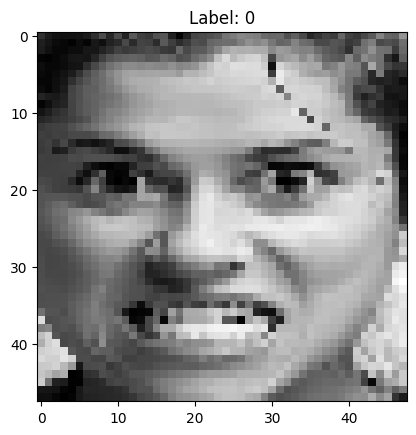

In [ ]:
# sanity check

import matplotlib.pyplot as plt

plt.imshow(X[0], cmap='gray')
plt.title(f"Label: {y[0]}")
plt.show()

In [ ]:
# normalize pixel values
X = X / 255.0

In [ ]:
from sklearn.model_selection import train_test_split

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# cnn prep

X = X / 255.0

import torch

# reshape for CNN: (N, 1, 48, 48)
X_train_cnn = torch.tensor(X_train).unsqueeze(1).float()
X_test_cnn = torch.tensor(X_test).unsqueeze(1).float()

y_train_t = torch.tensor(y_train).long()
y_test_t = torch.tensor(y_test).long()

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_cnn, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
# compute hog after splitting
from skimage.feature import hog

# HOG parameters
hog_params = {
    'orientations': 9,
    'pixels_per_cell': (8, 8),
    'cells_per_block': (2, 2),
    'block_norm': 'L2-Hys',
    'transform_sqrt': True
}

X_train_hog = np.array([hog(img, **hog_params) for img in X_train])
X_test_hog  = np.array([hog(img, **hog_params) for img in X_test])

print("HOG train shape:", X_train_hog.shape)
print("HOG test shape:", X_test_hog.shape)

HOG train shape: (4446, 900)
HOG test shape: (1112, 900)


In [ ]:
# flatten images

X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print("Flattened shape:", X_train_flat.shape)

Flattened shape: (4446, 2304)


In [ ]:
#train model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_flat, y_train)

from sklearn.neighbors import KNeighborsClassifier

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_flat, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


KNeighborsClassifier()

The work above only used raw pixel data, how would the accuracy change if we extracted HOG (Histogram of Oriented Gradients) features from the pictures?


In [ ]:
# logistic reg
from sklearn.linear_model import LogisticRegression

model_hog = LogisticRegression(max_iter=1000)
model_hog.fit(X_train_hog, y_train)

# KNN
from sklearn.neighbors import KNeighborsClassifier

knn_hog = KNeighborsClassifier(n_neighbors=5)
knn_hog.fit(X_train_hog, y_train)

KNeighborsClassifier()

In [ ]:
from sklearn.metrics import accuracy_score
import pandas as pd

# Logistic Regression
# Raw pixels
y_pred_lr_pixels = model.predict(X_test_flat)
acc_lr_pixels = accuracy_score(y_test, y_pred_lr_pixels)

# HOG features
y_pred_lr_hog = model_hog.predict(X_test_hog)
acc_lr_hog = accuracy_score(y_test, y_pred_lr_hog)

# KNN
# Raw pixels
y_pred_knn_pixels = knn.predict(X_test_flat)
acc_knn_pixels = accuracy_score(y_test, y_pred_knn_pixels)

# HOG features
y_pred_knn_hog = knn_hog.predict(X_test_hog)
acc_knn_hog = accuracy_score(y_test, y_pred_knn_hog)

# summary table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Logistic Regression', 'KNN', 'KNN'],
    'Feature Type': ['Raw Pixels', 'HOG Features', 'Raw Pixels', 'HOG Features'],
    'Test Accuracy': [acc_lr_pixels, acc_lr_hog, acc_knn_pixels, acc_knn_hog]
})

print(results)

                 Model  Feature Type  Test Accuracy
0  Logistic Regression    Raw Pixels       0.361511
1  Logistic Regression  HOG Features       0.456835
2                  KNN    Raw Pixels       0.284173
3                  KNN  HOG Features       0.427158


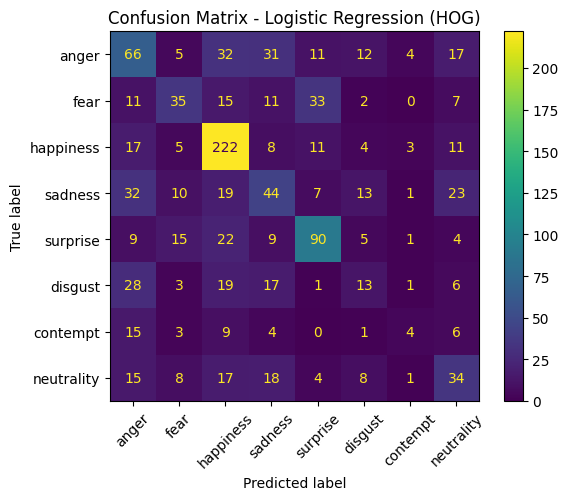

In [ ]:
# gaining a little more insight before CNN

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# confusion matrix for Logistic Regression (HOG)
cm = confusion_matrix(y_test, y_pred_lr_hog)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotions)
disp.plot(xticks_rotation=45)

plt.title("Confusion Matrix - Logistic Regression (HOG)")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report - Logistic Regression (HOG):")
print(classification_report(y_test, y_pred_lr_hog, target_names=emotions))

Classification Report - Logistic Regression (HOG):
              precision    recall  f1-score   support

       anger       0.34      0.37      0.36       178
        fear       0.42      0.31      0.35       114
   happiness       0.63      0.79      0.70       281
     sadness       0.31      0.30      0.30       149
    surprise       0.57      0.58      0.58       155
     disgust       0.22      0.15      0.18        88
    contempt       0.27      0.10      0.14        42
  neutrality       0.31      0.32      0.32       105

    accuracy                           0.46      1112
   macro avg       0.38      0.36      0.37      1112
weighted avg       0.43      0.46      0.44      1112



In [ ]:
# CNN

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.fc1 = nn.Linear(64*10*10, 128)
        self.fc2 = nn.Linear(128, 8)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # (48 → 46 → 23)
        x = self.pool(self.relu(self.conv2(x)))   # (23 → 21 → 10)

        x = x.view(-1, 64*10*10)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [ ]:
# training the model

model_cnn = CNN()

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

epochs = 15

for epoch in range(epochs):
    total_loss = 0

    for batch_X, batch_y in train_loader:
        outputs = model_cnn(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 288.8023
Epoch 2, Loss: 276.2315
Epoch 3, Loss: 261.9184
Epoch 4, Loss: 252.7582
Epoch 5, Loss: 248.0126
Epoch 6, Loss: 241.1820
Epoch 7, Loss: 236.8764
Epoch 8, Loss: 228.3341
Epoch 9, Loss: 223.5605
Epoch 10, Loss: 216.2362
Epoch 11, Loss: 213.2455
Epoch 12, Loss: 205.2350
Epoch 13, Loss: 201.8693
Epoch 14, Loss: 195.7058
Epoch 15, Loss: 191.9505


In [ ]:
# evaluating cnn

with torch.no_grad():
    outputs = model_cnn(X_test_cnn)
    _, predicted = torch.max(outputs, 1)

y_pred_cnn = predicted.numpy()

from sklearn.metrics import accuracy_score
cnn_acc = accuracy_score(y_test, y_pred_cnn)

print("CNN Accuracy:", cnn_acc)

CNN Accuracy: 0.3857913669064748


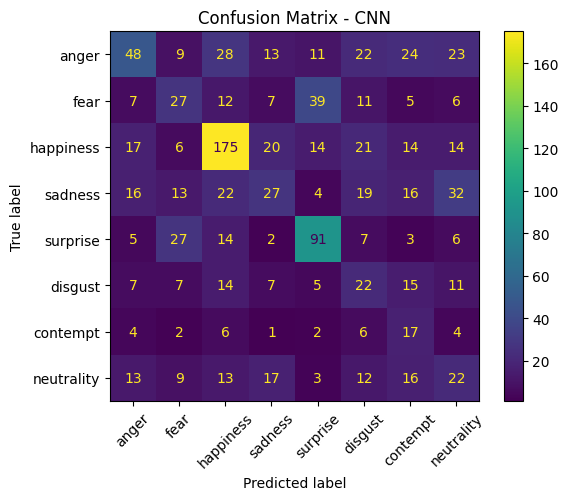

In [ ]:
# confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_cnn = confusion_matrix(y_test, y_pred_cnn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=emotions)
disp.plot(xticks_rotation=45)

plt.title("Confusion Matrix - CNN")
plt.show()

At this point, the model is not learning accurately. We're going to try mini-batch training and class weighting

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset, random_split

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
train_dataset = EmotionDataset(X_train, y_train, transform=transform_train)
test_dataset = EmotionDataset(X_test, y_test, transform=transform_test)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

In [ ]:
from torch.utils.data import WeightedRandomSampler
import numpy as np

# Get indices of the subset
train_indices = train_dataset.indices

# Get labels ONLY for training subset
train_labels = np.array(y_train)[train_indices]

# Compute class counts
class_counts = np.bincount(train_labels)

# Avoid division by zero
class_weights_np = 1. / (class_counts + 1e-6)

# Assign weight per sample
sample_weights = class_weights_np[train_labels]

# Convert to torch tensor (important!)
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
class BetterCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(128 * 6 * 6, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 8)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [ ]:
model = BetterCNN().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=30):
    best_val_loss = float('inf')
    patience = 5
    trigger_times = 0

    for epoch in range(epochs):
        # train
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)

                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total

        print(f"Epoch {epoch+1}:")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

        # early stop
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger_times = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print("Early stopping triggered")
                break

In [ ]:
train_model(model, train_loader, val_loader, epochs=50)

Epoch 1:
  Train Loss: 118.9532, Train Acc: 0.1732
  Val Loss:   14.7505, Val Acc:   0.0719
Epoch 2:
  Train Loss: 112.2559, Train Acc: 0.2057
  Val Loss:   14.7955, Val Acc:   0.1213
Epoch 3:
  Train Loss: 107.7620, Train Acc: 0.2202
  Val Loss:   14.5597, Val Acc:   0.1101
Epoch 4:
  Train Loss: 107.3433, Train Acc: 0.2312
  Val Loss:   14.0460, Val Acc:   0.1191
Epoch 5:
  Train Loss: 104.6077, Train Acc: 0.2472
  Val Loss:   14.8267, Val Acc:   0.1079
Epoch 6:
  Train Loss: 103.6652, Train Acc: 0.2342
  Val Loss:   14.0334, Val Acc:   0.1191
Epoch 7:
  Train Loss: 103.6275, Train Acc: 0.2374
  Val Loss:   13.9871, Val Acc:   0.1348
Epoch 8:
  Train Loss: 102.4277, Train Acc: 0.2354
  Val Loss:   13.9567, Val Acc:   0.1393
Epoch 9:
  Train Loss: 99.9505, Train Acc: 0.2637
  Val Loss:   13.3709, Val Acc:   0.1708
Epoch 10:
  Train Loss: 97.9574, Train Acc: 0.2729
  Val Loss:   13.5052, Val Acc:   0.1753
Epoch 11:
  Train Loss: 96.8674, Train Acc: 0.2757
  Val Loss:   13.1687, Val Acc

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print("Test Accuracy:", correct / total)

Test Accuracy: 0.3102517985611511


<Figure size 800x800 with 0 Axes>

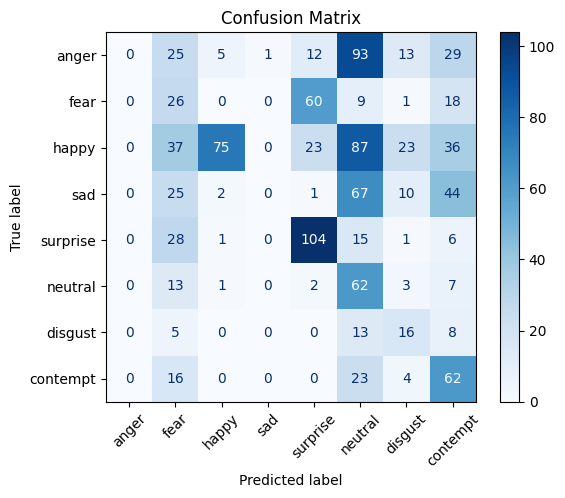

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

emotion_labels = ['anger', 'fear', 'happy', 'sad', 'surprise', 'neutral', 'disgust', 'contempt']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_labels)

plt.figure(figsize=(8,8))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()